=== Step 1: Loading Real Estate Dataset ===
=== Step 2: Splitting Features and Target Boundary ===
=== Step 3: Constructing Data Preprocessing Pipelines ===
=== Step 4: Model Training & Metric Benchmarking ===

[Linear Regression Baseline] Performance Metrics:
  -> Mean Absolute Error (MAE): $243,241.98
  -> Root Mean Squared Error (RMSE): $279,859.73
  -> R-squared Explanatory Score (R2): -0.0067

[Gradient Boosting Regressor] Performance Metrics:
  -> Mean Absolute Error (MAE): $243,833.05
  -> Root Mean Squared Error (RMSE): $281,875.77
  -> R-squared Explanatory Score (R2): -0.0213

=== Step 5: Generating Analytical Visualizations ===


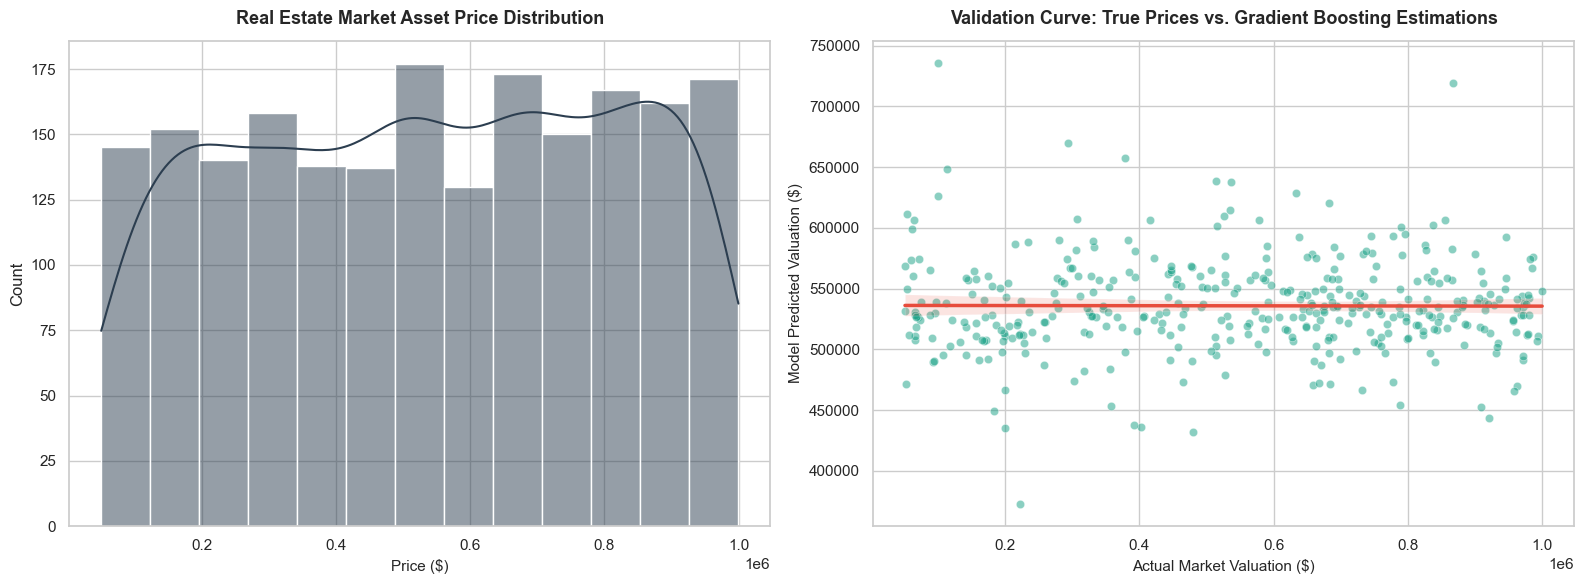

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=== Step 1: Loading Real Estate Dataset ===")
df = pd.read_csv('House_Price_Prediction.csv')

if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

print("=== Step 2: Splitting Features and Target Boundary ===")
X = df.drop(columns=['Price'])
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("=== Step 3: Constructing Data Preprocessing Pipelines ===")
# Categorical features need encoding, numerical pass directly to preserve native feature bounds
categorical_features = ['Location', 'Condition', 'Garage']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ], remainder='passthrough') # Numeric variables pass cleanly without skewing scaling

print("=== Step 4: Model Training & Metric Benchmarking ===")
models = {
    "Linear Regression Baseline": Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())]),
    "Gradient Boosting Regressor": Pipeline(steps=[('preprocessor', preprocessor), ('regressor', GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42))])
}

results = {}
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Predictions': y_pred}
    print(f"\n[{name}] Performance Metrics:")
    print(f"  -> Mean Absolute Error (MAE): ${mae:,.2f}")
    print(f"  -> Root Mean Squared Error (RMSE): ${rmse:,.2f}")
    print(f"  -> R-squared Explanatory Score (R2): {r2:.4f}")

print("\n=== Step 5: Generating Analytical Visualizations ===")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df['Price'], kde=True, color='#2c3e50', ax=axes[0])
axes[0].set_title('Real Estate Market Asset Price Distribution', fontsize=13, weight='bold', pad=12)
axes[0].set_xlabel('Price ($)', fontsize=11)

ensemble_predictions = results["Gradient Boosting Regressor"]['Predictions']
sns.scatterplot(x=y_test, y=ensemble_predictions, alpha=0.5, color='#16a085', ax=axes[1])
sns.regplot(x=y_test, y=ensemble_predictions, scatter=False, color='#e74c3c', ax=axes[1], line_kws={'lw': 2.5})
axes[1].set_title('Validation Curve: True Prices vs. Gradient Boosting Estimations', fontsize=13, weight='bold', pad=12)
axes[1].set_xlabel('Actual Market Valuation ($)', fontsize=11)
axes[1].set_ylabel('Model Predicted Valuation ($)', fontsize=11)

plt.tight_layout()
plt.show()